[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/halla-ai/deepnlp-2026/blob/main/notebooks/week-06.ipynb)

# 6주차 실습: 멀티모달 표현의 결합

**목표.** 제주 공개 사진 5장으로 세 가지를 해 본다.

1. **CLIP 제로샷 분류**: 사진과 후보 문장의 유사도 히트맵을 그리고, 라벨 언어(영어/한국어)가 결과를 어떻게 바꾸는지 본다
2. **SmolVLM 질의응답**: 사진을 언어모형에 넣고 질문해 답을 얻는다. **사진만 바꿔** 답이 사진을 따라 움직이는지(근거), 한국어 질문이 어떻게 깨지는지(언어 편향) 확인한다
3. **텍스트 전용 모델과 비교, 시각 토큰 세기**: 같은 질문을 사진 없이 텍스트 전용 모델에 주면 무엇이 나오는지 보고, 사진 1장이 문맥에서 몇 토큰을 쓰는지와 그 수를 정하는 것이 무엇인지 잰다

GPU는 필요 없다. 노트북이 실행 시점에 사진과 모델을 내려받는다. 사진은 위키미디어 공용과 공공누리의 제주 공개 사진이고, 출처와 라이선스는 강의 노트 6주차 [사진 출처] 표에 있다.

## 0. 준비

- 실행 기록: 2026-09-30, 로컬 Windows CPU, 스레드 4개, 탐욕 디코딩 사용.
- 원본 노트북 골격 유지. TODO의 `MY_IMAGE`를 `udo`로 변경.
- 환경 재현을 위한 라이브러리 버전과 모델 revision 고정, CPU 스레드 제한, 명시적 attention mask 전달 보완.
- transformers 4.57.6에서 프로세서 호출 인자의 `do_image_splitting`이 무시되는 문제를 확인. `build_inputs`에서 이미지 프로세서 속성을 임시 변경 후 복원하도록 호환성 보완.
- 설치되지 않은 패키지는 아래 셀에서 설치. 이미 호환 환경이면 설치 생략.
- 출력에 포함된 시간은 이 컴퓨터의 관측치이며 모델 다운로드 및 로딩 시간 제외. 답변과 수치의 해석은 실제 실행 후 기록.

In [1]:
# Colab 또는 별도 Python 환경에서 필요한 라이브러리 준비
import importlib.metadata as metadata
import subprocess
import sys

requirements = {
    "transformers": "transformers==4.57.6",
    "torch": "torch>=2.8,<2.9",
    "torchvision": "torchvision>=0.23,<0.24",
    "Pillow": "Pillow",
    "matplotlib": "matplotlib",
    "accelerate": "accelerate",
}
missing = []
for package, requirement in requirements.items():
    try:
        version = metadata.version(package)
        if package == "transformers" and version != "4.57.6":
            missing.append(requirement)
    except metadata.PackageNotFoundError:
        missing.append(requirement)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import platform
import torch
torch.set_num_threads(4)
torch.manual_seed(202221015)
print("Python:", platform.python_version(), "OS:", platform.system(), platform.release())
print("실험 장치: CPU / torch threads:", torch.get_num_threads())
for package in requirements:
    print(f"{package}: {metadata.version(package)}")

Python: 3.10.0 OS: Windows 10
실험 장치: CPU / torch threads: 4
transformers: 4.57.6
torch: 2.8.0+cu128
torchvision: 0.23.0+cu128
Pillow: 12.3.0
matplotlib: 3.10.9
accelerate: 1.12.0


## 1. 먼저 그냥 실행해 보기

아래 셀들을 위에서부터 차례로 실행하세요. 아무것도 고치지 않아도 끝까지 돌아갑니다.

### 1-1. 제주 공개 사진 5장 내려받기

위키미디어 공용(및 공공누리)에서 라이선스가 확인된 제주 사진 5장을 내려받는다. 강의 노트의 실측과 같은 사진이다.

In [2]:
import urllib.request
import time

IMAGES = {
    # 파일명: (다운로드 주소, 위키미디어 공용 원본 제목)
    "seongsan-sunrise": (
        "https://upload.wikimedia.org/wikipedia/commons/thumb/f/f4/Sunrise_with_Seongsan_Ilchulbong.jpg/960px-Sunrise_with_Seongsan_Ilchulbong.jpg",
        "Sunrise with Seongsan Ilchulbong",
    ),
    "seongsan-carpark": (
        "https://upload.wikimedia.org/wikipedia/commons/thumb/b/b0/Sunrise_peak_carpark_-_panoramio.jpg/960px-Sunrise_peak_carpark_-_panoramio.jpg",
        "Sunrise peak carpark - panoramio",
    ),
    "hallasan-yeongsil": (
        "https://upload.wikimedia.org/wikipedia/commons/thumb/e/e5/Wooden_staircase_along_Yeongsil_Trail_with_the_mountains_of_Hallasan_Park_Jeju_Island_South_Korea.jpg/960px-Wooden_staircase_along_Yeongsil_Trail_with_the_mountains_of_Hallasan_Park_Jeju_Island_South_Korea.jpg",
        "Wooden staircase along Yeongsil Trail",
    ),
    "manjanggul": (
        "https://upload.wikimedia.org/wikipedia/commons/8/80/Lava_Manjanggul_Cave.jpg",
        "Lava Manjanggul Cave",
    ),
    "udo": (
        "https://upload.wikimedia.org/wikipedia/commons/thumb/0/04/Udo%2C_Jeju_Province%2C_South_Korea_02.jpg/960px-Udo%2C_Jeju_Province%2C_South_Korea_02.jpg",
        "Udo, Jeju Province, South Korea 02",
    ),
}

import os
os.makedirs("week06-imgs", exist_ok=True)

def fetch(url, tries=4):
    # 위키미디어는 짧은 시간에 요청이 몰리면 429를 돌려준다. 기다렸다 다시 요청한다.
    for k in range(tries):
        req = urllib.request.Request(url, headers={"User-Agent": "deepnlp-course/1.0"})
        try:
            with urllib.request.urlopen(req, timeout=60) as r:
                return r.read()
        except urllib.error.HTTPError as e:
            if e.code == 429 and k < tries - 1:
                wait = 15 * (k + 1)
                print(f"  429, {wait}초 후 재시도 ({k + 1}/{tries - 1})")
                time.sleep(wait)
            else:
                raise

for name, (url, _title) in IMAGES.items():
    path = f"week06-imgs/{name}.jpg"
    if not os.path.exists(path):
        data = fetch(url)
        with open(path, "wb") as f:
            f.write(data)
    print(f"{path}: {os.path.getsize(path) // 1024} KB")

week06-imgs/seongsan-sunrise.jpg: 47 KB
week06-imgs/seongsan-carpark.jpg: 151 KB
week06-imgs/hallasan-yeongsil.jpg: 182 KB
week06-imgs/manjanggul.jpg: 188 KB
week06-imgs/udo.jpg: 135 KB


### 1-2. 사진 한눈에 보기

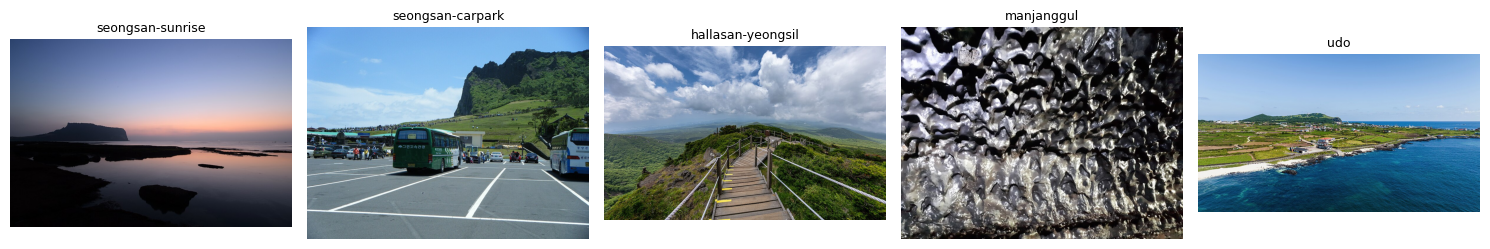

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, (name, (_url, title)) in zip(axes, IMAGES.items()):
    img = Image.open(f"week06-imgs/{name}.jpg").convert("RGB")
    ax.imshow(img)
    ax.set_title(name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

### 1-3. CLIP 제로샷 - 사진과 문장의 유사도

CLIP은 이미지 인코더와 텍스트 인코더 **둘**을 가진다. 이미지 인코더는 ViT-B/32다. 사진을 224x224로 맞춘 뒤 32x32 픽셀 조각(패치) 7x7=49개로 잘라 조각 하나를 토큰처럼 읽는다. 두 인코더가 각자 벡터를 만들고, 벡터를 길이 1로 정규화한 뒤 내적하면 코사인 유사도가 나온다.

사진 5장 x 후보 문장 5개의 유사도 행렬을 만들어 본다. 각 행에서 가장 큰 값이 모델이 고른 문장이다.

In [4]:
import torch
from transformers import CLIPModel, CLIPProcessor

clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32", revision="3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268").eval()
clip_proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32", revision="3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268")

print(f"logit_scale: {clip.logit_scale.exp().item():.1f}")

def clip_similarity(image_paths, texts):
    # 이미지와 문장을 각자 인코딩해 정규화한 뒤 내적한다
    imgs = [Image.open(p).convert("RGB") for p in image_paths]
    with torch.no_grad():
        img_inputs = clip_proc(images=imgs, return_tensors="pt")
        img_emb = clip.get_image_features(pixel_values=img_inputs["pixel_values"])
        if hasattr(img_emb, "pooler_output"):
            img_emb = img_emb.pooler_output
        txt_inputs = clip_proc(text=texts, return_tensors="pt", padding=True)
        txt_emb = clip.get_text_features(
            input_ids=txt_inputs["input_ids"], attention_mask=txt_inputs["attention_mask"]
        )
        if hasattr(txt_emb, "pooler_output"):
            txt_emb = txt_emb.pooler_output
        img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
        txt_emb = txt_emb / txt_emb.norm(dim=-1, keepdim=True)
        return (img_emb @ txt_emb.T).tolist()

# 동작 확인: 첫 사진 1장, 짧은 영어 라벨 5개
labels_en_coarse = [
    "a photo of a sunrise peak",
    "a photo of a parking lot",
    "a photo of a hiking trail",
    "a photo of a lava tube cave",
    "a photo of a coastal island",
]
paths = [f"week06-imgs/{name}.jpg" for name in IMAGES]
sim = clip_similarity(paths, labels_en_coarse)
print(f"\n{IMAGES['seongsan-sunrise'][1]} 행:")
for lab, v in zip(labels_en_coarse, sim[0]):
    print(f"  {v:+.3f}  {lab}")

C:\Users\User\Desktop\School2\tmp\deepnlp_20260930\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


logit_scale: 100.0



Sunrise with Seongsan Ilchulbong 행:
  +0.266  a photo of a sunrise peak
  +0.222  a photo of a parking lot
  +0.227  a photo of a hiking trail
  +0.184  a photo of a lava tube cave
  +0.274  a photo of a coastal island


### 1-4. 라벨 언어가 결과를 바꾼다 - 유사도 히트맵

같은 사진 5장에 라벨 조합을 네 가지로 바꿔가며 제로샷 분류를 돌린다.

- **영어 (짧은)**: `a photo of a ...` 뒤에 짧은 영어 라벨
- **영어 (장면 묘사)**: 장면을 묘사하는 긴 영어 라벨
- **한국어**: `... 사진` 형식의 한국어 라벨
- **한국어 + 영어 섞기**: 한국어 라벨에 영어를 괄호로 붙임

라벨 조합마다 **각 사진이 고른 라벨**도 출력한다. 한국어 라벨에서 여러 사진이 같은 라벨로 쏠리는지 보자.

히트맵에서 행: 사진, 열: 후보 라벨이다. 가장 진한 칸이 모델이 고른 라벨이고, **대각선이 진하면 정답을 골라낸 것**이다.

en_coarse: 대각선 정답 4/5
    seongsan-sunrise   -> a photo of a coastal island  (오답)
    seongsan-carpark   -> a photo of a parking lot
    hallasan-yeongsil  -> a photo of a hiking trail
    manjanggul         -> a photo of a lava tube cave
    udo                -> a photo of a coastal island


en_scenario: 대각선 정답 5/5
    seongsan-sunrise   -> a photo of a sunrise over a volcanic crater by the sea
    seongsan-carpark   -> a photo of a parking lot full of tour buses
    hallasan-yeongsil  -> a photo of a wooden staircase on a forest hiking trail
    manjanggul         -> a photo of a dark lava tube cave interior
    udo                -> a photo of green sea cliffs and a small island


ko: 대각선 정답 1/5
    seongsan-sunrise   -> 성산일출봉 사진
    seongsan-carpark   -> 성산일출봉 사진  (오답)
    hallasan-yeongsil  -> 성산일출봉 사진  (오답)
    manjanggul         -> 성산일출봉 사진  (오답)
    udo                -> 주차장 사진  (오답)


ko_english_mix: 대각선 정답 4/5
    seongsan-sunrise   -> 해안 섬 (coastal island) photo  (오답)
    seongsan-carpark   -> 주차장 (parking lot) photo
    hallasan-yeongsil  -> 등산로 (hiking trail) photo
    manjanggul         -> 용암동굴 (lava tube cave) photo
    udo                -> 해안 섬 (coastal island) photo


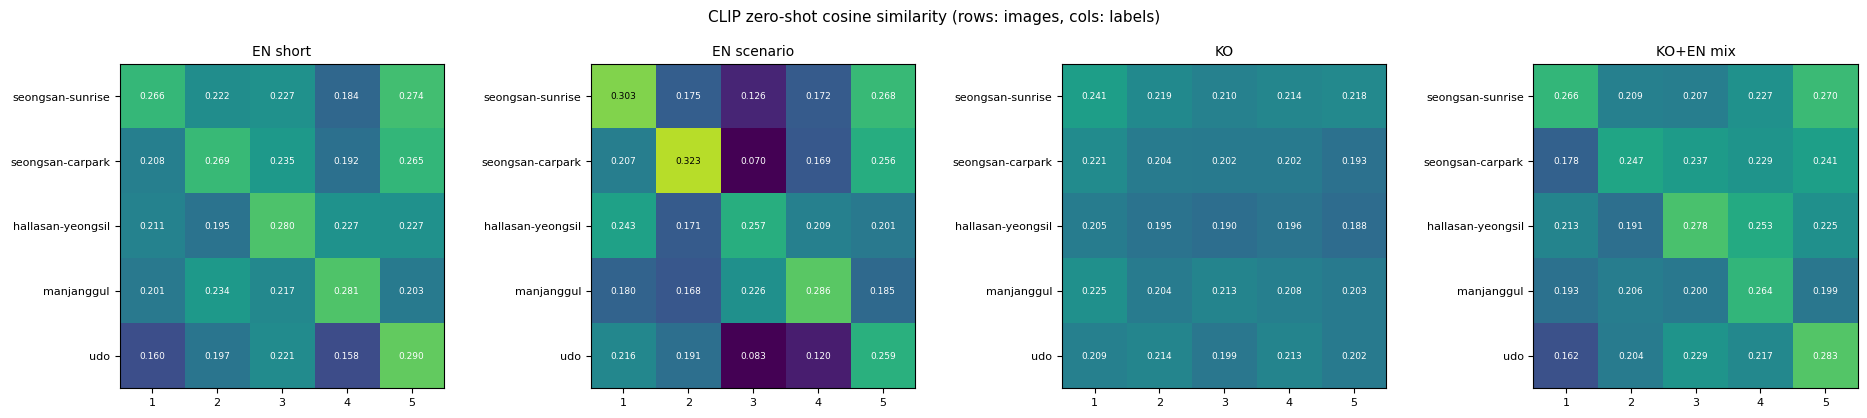

열 라벨 번호:
  en_coarse: 1=a photo of a sunrise peak, 2=a photo of a parking lot, 3=a photo of a hiking trail, 4=a photo of a lava tube cave, 5=a photo of a coastal island
  en_scenario: 1=a photo of a sunrise over a volcanic crater by the sea, 2=a photo of a parking lot full of tour buses, 3=a photo of a wooden staircase on a forest hiking trail, 4=a photo of a dark lava tube cave interior, 5=a photo of green sea cliffs and a small island
  ko: 1=성산일출봉 사진, 2=주차장 사진, 3=등산로 사진, 4=용암동굴 사진, 5=해안 섬 사진
  ko_english_mix: 1=성산일출봉 (Seongsan Ilchulbong) sunrise peak photo, 2=주차장 (parking lot) photo, 3=등산로 (hiking trail) photo, 4=용암동굴 (lava tube cave) photo, 5=해안 섬 (coastal island) photo


In [5]:
LABEL_SETS = {
    "en_coarse": labels_en_coarse,
    "en_scenario": [
        "a photo of a sunrise over a volcanic crater by the sea",
        "a photo of a parking lot full of tour buses",
        "a photo of a wooden staircase on a forest hiking trail",
        "a photo of a dark lava tube cave interior",
        "a photo of green sea cliffs and a small island",
    ],
    "ko": [
        "성산일출봉 사진",
        "주차장 사진",
        "등산로 사진",
        "용암동굴 사진",
        "해안 섬 사진",
    ],
    "ko_english_mix": [
        "성산일출봉 (Seongsan Ilchulbong) sunrise peak photo",
        "주차장 (parking lot) photo",
        "등산로 (hiking trail) photo",
        "용암동굴 (lava tube cave) photo",
        "해안 섬 (coastal island) photo",
    ],
}

img_names = list(IMAGES)
all_sims = {}
for set_name, labels in LABEL_SETS.items():
    all_sims[set_name] = clip_similarity(paths, labels)
    correct = sum(1 for i in range(len(paths)) if max(range(len(labels)), key=lambda j: all_sims[set_name][i][j]) == i)
    print(f"{set_name}: 대각선 정답 {correct}/{len(paths)}")
    for i, name in enumerate(img_names):
        j = max(range(len(labels)), key=lambda j: all_sims[set_name][i][j])
        print(f"    {name:<18} -> {labels[j]}{'' if j == i else '  (오답)'}")

fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
short = {"en_coarse": "EN short", "en_scenario": "EN scenario", "ko": "KO", "ko_english_mix": "KO+EN mix"}
for ax, (set_name, labels) in zip(axes, LABEL_SETS.items()):
    data = all_sims[set_name]
    ax.imshow(data, cmap="viridis", vmin=0.1, vmax=0.35)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(range(1, len(labels) + 1), fontsize=8)
    ax.set_yticks(range(len(img_names)))
    ax.set_yticklabels(img_names, fontsize=8)
    for i in range(len(paths)):
        for j in range(len(labels)):
            ax.text(j, i, f"{data[i][j]:.3f}", ha="center", va="center", fontsize=6.5,
                    color="white" if data[i][j] < 0.3 else "black")
    ax.set_title(short[set_name], fontsize=10)
plt.suptitle("CLIP zero-shot cosine similarity (rows: images, cols: labels)", fontsize=11)
plt.tight_layout()
plt.show()

print("열 라벨 번호:")
for set_name, labels in LABEL_SETS.items():
    print(f"  {set_name}: " + ", ".join(f"{j+1}={l}" for j, l in enumerate(labels)))

### 1-5. 한국어 라벨은 토큰에서 어떻게 되는가

한국어 라벨이 무너지는 원인을 토큰에서 확인한다. CLIP의 토크나이저는 한국어 글자를 **바이트 조각**으로 자른다. 한글 한 글자는 UTF-8로 3바이트라서 보통 1~2개 조각이 된다. CLIP의 텍스트 인코더는 한 문장에 토큰을 77개까지만 받으므로, 한국어는 같은 길이의 영어보다 이 한도에 빨리 닿는다. 토큰 자체는 만들어지므로 무너지는 원인은 토큰화가 아니라, 그 토큰들이 사진 내용과 짝지어져 학습된 일이 드물다는 것(학습 데이터가 영어 위주)이다. 그래서 다섯 한국어 라벨의 벡터가 서로 거의 구별되지 않는다.

In [6]:
ko_text = "성산일출봉 사진"
ko_inputs = clip_proc(text=[ko_text], return_tensors="pt")
ko_ids = ko_inputs["input_ids"][0].tolist()
en_text = "a photo of a sunrise peak"
en_inputs = clip_proc(text=[en_text], return_tensors="pt")
en_ids = en_inputs["input_ids"][0].tolist()

print(f"한국어 '{ko_text}' -> 토큰 {len(ko_ids)}개: {ko_ids}")
print(f"영어   '{en_text}' -> 토큰 {len(en_ids)}개: {en_ids}")
print(f"'성' 한 글자 -> 조각 {len(clip_proc.tokenizer('성', add_special_tokens=False).input_ids)}개: {clip_proc.tokenizer.tokenize('성')}")
print(f"어휘 크기: {clip.config.text_config.vocab_size} (바이트 단위 BPE 어휘 전체)")
print()
print("한국어는 글자가 바이트 조각으로 분해된다. 토큰은 만들어지지만,")
print("그 토큰들이 사진 내용과 짝지어져 학습된 일이 드물어 라벨끼리 벡터가 거의 구별되지 않는다.")

한국어 '성산일출봉 사진' -> 토큰 14개: [49406, 15074, 109, 31061, 108, 43406, 42476, 39810, 112, 487, 31061, 105, 38890, 49407]
영어   'a photo of a sunrise peak' -> 토큰 8개: [49406, 320, 1125, 539, 320, 5610, 6026, 49407]
'성' 한 글자 -> 조각 2개: ['ìĦ', '±</w>']
어휘 크기: 49408 (바이트 단위 BPE 어휘 전체)

한국어는 글자가 바이트 조각으로 분해된다. 토큰은 만들어지지만,
그 토큰들이 사진 내용과 짝지어져 학습된 일이 드물어 라벨끼리 벡터가 거의 구별되지 않는다.


### 1-6. SmolVLM 질의응답 - 사진을 언어모형에 넣기

이제 생성형이다. SmolVLM-256M-Instruct는 사진을 **시각 토큰**으로 바꿔 언어모형의 문맥에 끼워 넣는다.

시각 토큰 수는 **타일 분할** 설정이 크게 바꾼다.

- 분할을 켜면(모델 기본값) 사진을 긴 변 2048로 키운 뒤 512x512 타일로 자르고, 전체 사진 축소본 1장을 더한다. 타일 1장이 64토큰이므로 960x640 사진은 타일 12장 + 1장 = 13장 x 64 = **832토큰**이다
- 분할을 끄면 전체 사진 1장만 넣어 **64토큰**이다

분할을 켜면 CPU에서 답 하나에 수십 초가 걸린다. 그래서 이 노트북은 **분할을 끄고(`SPLIT = False`) 답을 생성한다.** 분할을 켰을 때와의 차이는 1-10에서 직접 잰다.

절차는 세 단계다.

1. 채팅 템플릿으로 대화 형식 프롬프트를 조립한다 (이미지 자리는 표시자로 둔다)
2. 사진과 프롬프트를 프로세서에 넣어 모델 입력을 만든다
3. `generate()`로 답을 생성한다

In [7]:
from transformers import AutoProcessor, AutoModelForImageTextToText

vlm_name = "HuggingFaceTB/SmolVLM-256M-Instruct"
vlm_processor = AutoProcessor.from_pretrained(vlm_name, revision="7e3e67edbbed1bf9888184d9df282b700a323964")
vlm = AutoModelForImageTextToText.from_pretrained(vlm_name, revision="7e3e67edbbed1bf9888184d9df282b700a323964").eval()

SPLIT = False  # 타일 분할. False면 사진 1장이 시각 토큰 64개가 되어 CPU에서도 빠르게 답한다
vlm_processor.image_processor.do_image_splitting = SPLIT

total_params = sum(p.numel() for p in vlm.parameters())
print(f"전체 파라미터: {total_params:,}")

def build_inputs(img, question, split=None):
    # 채팅 템플릿으로 프롬프트를 만들고 사진과 함께 모델 입력으로 바꾼다
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": question}]}]
    prompt = vlm_processor.apply_chat_template(messages, add_generation_prompt=True)
    # 4.57.6에서는 호출 인자 대신 이미지 프로세서 속성으로 분할 제어
    previous_split = vlm_processor.image_processor.do_image_splitting
    if split is not None:
        vlm_processor.image_processor.do_image_splitting = split
    try:
        return vlm_processor(images=img, text=prompt, return_tensors="pt")
    finally:
        vlm_processor.image_processor.do_image_splitting = previous_split

def vlm_ask(image_path, question, max_new_tokens=48):
    # 사진과 질문을 넣어 답을 생성한다 (탐욕 디코딩이라 매번 같은 답)
    img = Image.open(image_path).convert("RGB")
    inputs = build_inputs(img, question)
    with torch.no_grad():
        out = vlm.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    text = vlm_processor.batch_decode(out, skip_special_tokens=True)[0]
    return text.split("Assistant:")[-1].strip()

def visual_token_count(img, split):
    # 입력 전체 토큰 수와 그중 시각 토큰(이미지 표시자) 수를 센다
    ids = build_inputs(img, "Describe this image.", split=split)["input_ids"][0].tolist()
    return len(ids), sum(1 for t in ids if t == vlm_processor.image_token_id)

first = "week06-imgs/seongsan-sunrise.jpg"
img0 = Image.open(first).convert("RGB")
for split in [True, False]:
    n_total, n_vis = visual_token_count(img0, split)
    print(f"분할 {'켬' if split else '끔'}: 입력 토큰 {n_total}개 중 시각 토큰 {n_vis}개 ({n_vis / n_total:.0%})")

print("\n동작 확인:")
q = "Describe this image in one sentence."
print(f"Q: {q}")
print(f"A: {vlm_ask(first, q)}")

전체 파라미터: 256,484,928


분할 켬: 입력 토큰 874개 중 시각 토큰 832개 (95%)
분할 끔: 입력 토큰 79개 중 시각 토큰 64개 (81%)

동작 확인:
Q: Describe this image in one sentence.


A: In this image, we can see the sky, water, and the hill.


### 1-7. 사진만 바꿔 보기 - 답이 사진을 따라 움직이는가

질문을 고정하고 **사진만** 다섯 장으로 바꿔 본다. 답이 사진 내용을 따라 바뀌면 답이 이미지에 근거(grounded) 있다는 뜻이다.

In [8]:
QUESTION_EN = "Describe this image in one sentence."
print(f"질문(고정): {QUESTION_EN}\n")
for name in IMAGES:
    path = f"week06-imgs/{name}.jpg"
    answer = vlm_ask(path, QUESTION_EN)
    print(f"[{name}]")
    print(f"  {answer}\n")

질문(고정): Describe this image in one sentence.



[seongsan-sunrise]
  In this image, we can see the sky, water, and the hill.



[seongsan-carpark]
  In this image we can see a group of vehicles on the road.



[hallasan-yeongsil]
  In this image we can see a bridge.



[manjanggul]
  In this image, there is a glass window.



[udo]
  In this image we can see a group of people, there are some trees, there is a water body, there are some mountains, there is a cloudy sky.



### 1-8. 한국어 질문은 어떻게 깨지는가

같은 사진들에 한국어 질문을 넣어 본다. 답이 영어로 나오거나, 질문과 상관없는 내용이 나오거나, 깨진 한글이 나온다. 영어 질문일 때보다 답이 사진에서 멀어지는 경우도 찾아보자.

원인은 모델 크기만이 아니라 **학습 데이터의 언어 분포**다. 256M 모델의 지시 학습 데이터는 영어 위주라 한국어 지시 뒤의 다음 토큰 확률이 무너진다.

In [9]:
QUESTION_KO = "이 이미지를 한 문장으로 묘사하라."
print(f"Q: {QUESTION_KO}\n")
for name in IMAGES:
    print(f"[{name}] {vlm_ask(f'week06-imgs/{name}.jpg', QUESTION_KO)}")

q2 = "여기가 어디인가? 주된 피사체가 무엇인가?"
print(f"\nQ: {q2}")
print(f"[seongsan-sunrise] {vlm_ask(first, q2)}")

Q: 이 이미지를 한 문장으로 묘사하라.



[seongsan-sunrise] The image shows a scenic view of a coastal area, likely a bay or a sea shore. The sky is clear with a deep blue hue, indicating a bright and sunny day. The sea is calm, with gentle waves lapping against the


[seongsan-carpark] 이 이미지를 한 문장으로 묘사하면 무없�


[hallasan-yeongsil] 이 이미지를 한 문장으로 묘사하면 무없�


[manjanggul] 이 이미지를 한 문장으로 묘사하면 무었�


[udo] The image shows a beautiful coastal landscape with a clear blue sky and a gentle breeze. The foreground is dominated by a large body of water, which appears to be a sea or a large body of water, possibly a bay or a large sea

Q: 여기가 어디인가? 주된 피사체가 무엇인가?


[seongsan-sunrise] 어디에서 이벤트를 이벤트를 이벤트를


### 1-9. 텍스트 전용 모델에게 같은 질문을 하면

온라인 학습활동의 비교다. 사진을 받을 수 없는 텍스트 전용 모델(Qwen3-0.6B-Base, 4·5주차와 같은 모델)에게 같은 질문을 준다. 사진이 없으니 모델은 **문맥만 보고 그럴듯한 장면을 지어낸다.** 답이 사진과 아무 관계가 없다는 것을 확인하자.

프롬프트 형식은 `Question: ...\nAnswer:`이고 탐욕 디코딩이라 매번 같은 답이 나온다.

In [10]:
from transformers import AutoTokenizer, AutoModelForCausalLM

txt_name = "Qwen/Qwen3-0.6B-Base"
txt_tok = AutoTokenizer.from_pretrained(txt_name, revision="da87bfb608c14b7cf20ba1ce41287e8de496c0cd")
txt_model = AutoModelForCausalLM.from_pretrained(txt_name, revision="da87bfb608c14b7cf20ba1ce41287e8de496c0cd").eval()

def text_only_ask(question, max_new_tokens=40):
    encoded = txt_tok(f"Question: {question}\nAnswer:", return_tensors="pt")
    ids = encoded.input_ids
    with torch.no_grad():
        out = txt_model.generate(ids, attention_mask=encoded.attention_mask, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=txt_tok.eos_token_id)
    return txt_tok.decode(out[0][ids.shape[1]:], skip_special_tokens=True).strip()

for q in ["Describe this image in one sentence.", "What is in this photo?", "사진 속에 나무가 몇 그루인가?"]:
    print(f"Q: {q}")
    print(f"  텍스트 전용: {text_only_ask(q)}")
    print(f"  SmolVLM (성산 사진): {vlm_ask(first, q)}\n")

Q: Describe this image in one sentence.


  텍스트 전용: The image depicts a serene landscape with a tranquil lake, lush greenery, and a lone figure in a flowing white dress, surrounded by a peaceful and serene atmosphere.


  SmolVLM (성산 사진): In this image, we can see the sky, water, and the hill.

Q: What is in this photo?


  텍스트 전용: The answer is a man in a white shirt and a man in a black shirt.
 A single-select problem: Is the question answered in a satisfactory fashion?

Available choices:
 (a). yes.
 (


  SmolVLM (성산 사진): A beautiful sunset over the sea. The sky is a deep blue, dotted with a few wispy clouds. The sun is setting, casting a golden glow over the sea. The sea is calm, with gentle ripples on its surface. There

Q: 사진 속에 나무가 몇 그루인가?


  텍스트 전용: 사진 속에 나무가 몇 그루인가에 대한 답은 상황에 따라 달라질 수 있습니다. 일반적으로 나무의 수는 몇 그루인지


  SmolVLM (성산 사진): The sea is calm and there are no waves.



### 1-10. 시각 토큰 수는 무엇이 정하나 - 크기, 비율, 분할

학습활동 [실무]의 지연·비용 보고를 위한 측정이다. 같은 사진을 여러 크기와 가로세로 비율로 바꿔 시각 토큰 수를 센다. **해상도를 올리면 토큰이 늘어날까?** 먼저 예상해 보고 실행하자.

마지막 줄은 분할을 켰을 때와 껐을 때 **첫 토큰이 나오기까지 걸린 시간**이다. 사진을 읽고 문맥을 처리하는 비용이 이 시간에 들어 있다. Colab 무료 CPU에서는 이보다 오래 걸릴 수 있다.

In [11]:
import time

print(f"{'크기':<12} {'분할 켬':>8} {'분할 끔':>8}")
for w, h in [(240, 160), (960, 640), (1920, 1280), (640, 640), (1280, 320)]:
    im = img0.resize((w, h))
    on, off = visual_token_count(im, True)[1], visual_token_count(im, False)[1]
    print(f"{w}x{h:<7} {on:>8} {off:>8}")

for split in [True, False]:
    inputs = build_inputs(img0, "Describe this image in one sentence.", split=split)
    t = time.time()
    with torch.no_grad():
        vlm.generate(**inputs, max_new_tokens=1, do_sample=False)
    print(f"분할 {'켬' if split else '끔'}: 입력 {inputs['input_ids'].shape[1]}토큰, 첫 토큰까지 {time.time() - t:.1f}초")

크기               분할 켬     분할 끔


240x160          832       64


960x640          832       64


1920x1280         832       64


640x640         1088       64
1280x320          320       64


분할 켬: 입력 877토큰, 첫 토큰까지 12.2초


분할 끔: 입력 82토큰, 첫 토큰까지 1.0초


## 2. 한 지점만 바꿔 보기 - 입력 이미지를 바꾼다

아래 셀의 `# TODO`로 표시된 **한 곳만** 바꾸고 다시 실행하세요.

> 규칙: `MY_IMAGE`를 다른 사진 이름으로 바꾼다. 후보는 `seongsan-sunrise`, `seongsan-carpark`, `hallasan-yeongsil`, `manjanggul`, `udo` 다섯 가지다. 바꾼 뒤 두 가지를 기록한다. (1) 같은 질문인데 답이 사진을 따라 바뀌는가. (2) 바꾼 사진의 특징이 답에 어떻게 반영되는가(또는 어두운 사진에서 답이 어떻게 무너지는가). 이것이 학습활동 [구현]의 기록이다.

In [12]:
# TODO: 사진 이름을 바꾼다. 후보: seongsan-sunrise / seongsan-carpark / hallasan-yeongsil / manjanggul / udo
MY_IMAGE = "udo"

# 아래는 그대로 둡니다
path = f"week06-imgs/{MY_IMAGE}.jpg"
print(f"사진: {MY_IMAGE}")
print(f"\n[영어 질문]")
q = "Describe this image in one sentence."
a = vlm_ask(path, q)
print(f"  Q: {q}")
print(f"  A: {a}")
print(f"\n[한국어 질문]")
q_ko = "이 이미지를 한 문장으로 묘사하라."
a_ko = vlm_ask(path, q_ko)
print(f"  Q: {q_ko}")
print(f"  A: {a_ko}")
print(f"\n[제로샷 - 이 사진은 다섯 라벨 중 어디에 가까운가]")
sim_one = clip_similarity([path], LABEL_SETS["en_coarse"])[0]
best = max(range(5), key=lambda j: sim_one[j])
for j, (lab, v) in enumerate(zip(LABEL_SETS["en_coarse"], sim_one)):
    mark = "  <-- 모델의 선택" if j == best else ""
    print(f"  {v:+.3f}  {lab}{mark}")

사진: udo

[영어 질문]


  Q: Describe this image in one sentence.
  A: In this image we can see a group of people, there are some trees, there is a water body, there are some mountains, there is a cloudy sky.

[한국어 질문]


  Q: 이 이미지를 한 문장으로 묘사하라.
  A: The image shows a beautiful coastal landscape with a clear blue sky and a gentle breeze. The foreground is dominated by a large body of water, which appears to be a sea or a large body of water, possibly a bay or a large sea

[제로샷 - 이 사진은 다섯 라벨 중 어디에 가까운가]
  +0.160  a photo of a sunrise peak
  +0.197  a photo of a parking lot
  +0.221  a photo of a hiking trail
  +0.158  a photo of a lava tube cave
  +0.290  a photo of a coastal island  <-- 모델의 선택


## 3. 정리 그래프

네 라벨 조합의 대각선 정답 수를 막대로 그린다. 라벨 언어가 제로샷을 어떻게 바꾸는지 한눈에 본다.

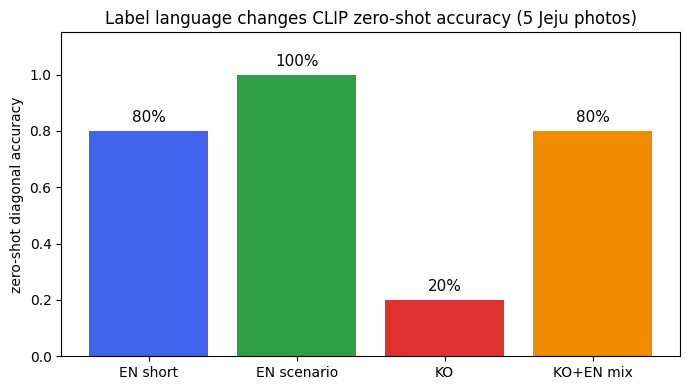

In [13]:
accs = {}
for set_name, labels in LABEL_SETS.items():
    accs[set_name] = sum(
        1 for i in range(len(paths)) if max(range(len(labels)), key=lambda j: all_sims[set_name][i][j]) == i
    ) / len(paths)

plt.figure(figsize=(7, 4))
names = [short[n] for n in LABEL_SETS]
vals = [accs[n] for n in LABEL_SETS]
bars = plt.bar(names, vals, color=["#4263eb", "#2f9e44", "#e03131", "#f08c00"])
for bar, v in zip(bars, vals):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 0.03, f"{v:.0%}", ha="center", fontsize=11)
plt.ylim(0, 1.15)
plt.ylabel("zero-shot diagonal accuracy")
plt.title("Label language changes CLIP zero-shot accuracy (5 Jeju photos)")
plt.tight_layout()
plt.show()

## 4. 확인 질문

1. 라벨 조합 네 가지의 대각선 정답 수는 각각 몇이었나요? 한국어 라벨에서 사진들은 어느 라벨로 쏠렸나요?
2. 영어 짧은 라벨에서 틀린 사진은 무엇이고, 두 후보의 유사도 차이는 얼마였나요? logit_scale 100을 곱하면 확률은 어떻게 갈리나요?
3. 1-7에서 사진을 바꿨을 때 답이 사진을 따라 바뀌었나요? 답에 사진에 없는 것이 들어간 경우가 있었나요?
4. 1-9에서 텍스트 전용 모델의 답은 사진과 어떤 관계였나요? 5주차의 어떤 개념과 이어지나요?
5. 1-10에서 해상도를 올리면 시각 토큰이 늘었나요? 토큰 수를 실제로 바꾼 것은 무엇이었나요?
6. 한국어 질문의 답은 어떤 모양이었나요? 질문 언어와 답 언어의 관계에서 관찰한 것을 한 문장으로 써 보세요.

답은 아래 셀에 글로 적으면 됩니다. 코드가 아니어도 됩니다.

□ 확인 질문 답변

1. 영어 짧은 라벨 4/5, 영어 장면 묘사 5/5, 한국어 1/5, 한국어+영어 4/5. 한국어는 성산 일출봉, 성산 주차장, 영실, 만장굴의 네 사진이 모두 "성산일출봉 사진"으로 쏠림. 우도는 "주차장 사진"으로 오분류. 따라서 한국어의 1/5는 안정적인 구별 능력의 증거가 아님.
2. 영어 짧은 라벨에서 성산 일출봉만 오답. `sunrise peak`의 코사인 0.266199, `coastal island`의 코사인 0.274222, 차이 0.008023. logit_scale 약 100을 곱한 로짓 차이는 0.8023, 두 확률의 비는 약 2.23배. 다섯 후보 전체에 softmax를 적용한 확률은 각각 0.306523, 0.683758. 이 확률은 주어진 후보끼리의 상대적 점수이며 정답 보장 확률이 아님.
3. 사진 변경에 따라 답변 대상은 달라짐. 성산 일출봉은 하늘, 물, 언덕이고 주차장은 차량 무리. 다만 영실 나무 계단길을 `bridge`, 만장굴 벽면을 `glass window`로 표현. 우도에서는 사진에서 확인되지 않는 `a group of people` 추가. 이미지에 반응하는 것과 정확하게 설명하는 것은 별개의 조건.
4. 텍스트 전용 모델은 사진을 전혀 입력받지 않았는데 고요한 호수와 흰 옷을 입은 사람, 흰색/검은색 셔츠의 남자 등을 생성. 주어진 성산 사진에서 근거를 찾을 수 없는 내용. 5주차 false acceptance와 연결되는 사례로, 자연스러운 다음 토큰 생성물을 참이라고 받아들이는 위험의 확인. 여기서 별도의 false acceptance 비율을 측정한 것은 아님.
5. 같은 3:2 비율의 240x160, 960x640, 1920x1280에서 분할을 켠 시각 토큰은 모두 832개. 원본 해상도 증가만으로 토큰 증가 없음. 분할 켬에서 1:1은 1088개, 4:1은 320개. 분할 끔에서는 모두 64개. 긴 변을 2048로 맞추고 512 타일 및 전체 사진 축소본을 더하는 규칙 때문에 비율과 분할 여부가 토큰 수를 결정.
6. 한국어 질문에도 영어 답이 나오거나, 주차장/영실/만장굴에서 `무없` 또는 `무었` 뒤의 깨진 문자로 끝나는 답이 출력됨. 추가 한국어 위치 질문에는 `어디에서 이벤트를 이벤트를 이벤트를`로 반복. 질문 언어만 바꾸어 한국어 지시 수행이나 사실성을 보장할 수 없음.

□ TODO 변경 기록

- 변경: `MY_IMAGE = "seongsan-sunrise"`에서 `MY_IMAGE = "udo"`로 변경.
- 고정 질문: `Describe this image in one sentence.`
- 이전 사진 응답: `In this image, we can see the sky, water, and the hill.`
- 변경 사진 응답: 사람 무리, 나무, 물, 산, 구름 낀 하늘을 나열하는 문장. 물과 초록 지형은 보이지만 사람 무리의 근거는 확인되지 않음. 우도 이미지에 맞춰 내용은 변했으나 환각도 포함.
- 한국어 질문 응답: 영어로 해안과 파란 하늘을 서술하며 사진만으로 확인할 수 없는 `a gentle breeze` 추가. 48토큰 상한으로 문장이 중간에서 끝남.
- CLIP의 우도 짧은 영어 라벨 최댓값은 `coastal island`, 코사인 약 0.290. 넓은 장면 분류 성공이 세부 QA의 정확성으로 이어지지는 않음.

□ 이론 정리

- CLIP은 이미지와 문장을 각각 인코딩한 뒤 같은 차원으로 투영. 벡터를 길이 1로 정규화한 뒤 내적으로 코사인 유사도 계산.
- 대조 학습은 배치의 실제 이미지-문장 쌍을 가깝게, 다른 조합을 멀게 배치. 이미지에서 문장, 문장에서 이미지의 두 분류 방향을 함께 학습.
- 실측의 정렬 실패: 한국어 라벨의 한 곳 쏠림, 성산 일출봉의 근소한 코사인 차이로 인한 오답. 생성 단계의 실패: 만장굴 벽면의 잘못된 물체 해석, 우도 사진의 확인되지 않는 사람 무리. 원본 강의의 예시 답을 옮기지 않고 이번 실행 출력으로 판정.
- 한국어 라벨도 토큰 생성 자체는 가능. 한국어 14토큰, 같은 대상의 짧은 영어 8토큰. 이 관찰만으로 훈련 데이터 분포를 실증한 것은 아니며, 강의에서 설명한 영어 중심 정렬의 해석과 함께 이해.


## 4-1. 과제 2: 해양 환경 관측 QA에 사진 모달리티 연결

□ 조건 상정

- 제주 해양 환경 관측 기록을 정리하는 가상의 소규모 조직. 기업 데이터 사용 없음.
- 월 2,000건의 관측 메모에 사진 1장 연결. 월 운영 예산 50,000원 중 계산 자원 20,000원, 검토 보조 업무 30,000원으로 가정. 실제 견적 및 실측 비용 아님.
- 계산 예산 환산 가정: CPU 작업자 1개를 시간당 1,000원에 전용 사용. 실측한 요청 처리 시간으로 계산 비용 추정. 외부 유료 API 사용 없음.
- 요구: 사진의 해안, 물, 하늘 등 눈에 보이는 내용의 초안. 첫 토큰 5초 이내를 시범 운영 목표로 설정. 수질, 오염 여부, 정확한 위치의 자동 판단 제외.
- QA 골격 `build_inputs`와 `vlm.generate` 재사용. 텍스트 질문에 우도 공개 사진을 연결. 질문: `Describe the visible coastline and water. Do not guess the location or water quality.`
- `split=False`와 `split=True`를 비교. 같은 이미지, 질문, CPU 스레드, 최대 생성 토큰, 탐욕 디코딩 유지.

□ 측정 정의

- 전처리: 채팅 프롬프트 조립, 이미지 분할, 텐서 생성까지의 시간.
- 첫 토큰: `generate(max_new_tokens=1)` 반환까지. 준비된 텐서 기준의 모델 처리 시간이며 UI에 글자가 표시되는 시간과 다름. 사진 전처리, 로딩, 다운로드 시간 제외.
- 사전 실행 1회 후 첫 토큰을 3회 측정하여 중앙값과 범위 보고. 전체 생성은 별도로 1회 측정. 전체 요청 시간은 해당 전처리 시간과 전체 생성 시간의 합.
- 시각/입력 점유율과 입력/모델 최대 문맥 점유율을 구분. 아래 코드에서 실제 모델 설정의 문맥 길이 조회.
- 사진 비율 변경 실험은 토큰 규칙 확인용 강제 resize이며, 실제 관측에 적용할 권장 전처리는 아님.

In [14]:
import statistics
import json
from time import perf_counter

scenario_image = Image.open(f"week06-imgs/{MY_IMAGE}.jpg").convert("RGB")
scenario_question = "Describe the visible coastline and water. Do not guess the location or water quality."
context_limit = vlm.config.text_config.max_position_embeddings
print("모델 최대 문맥 토큰:", context_limit)
print("시나리오 사진 원본 크기:", scenario_image.size)
print("모델 저장소 revision:", vlm.config._commit_hash)
print("CLIP revision:", clip.config._commit_hash)
print("텍스트 모델 revision:", txt_model.config._commit_hash)

token_rows = []
for w, h in [(240, 160), (960, 640), (1920, 1280), (640, 640), (1280, 320)]:
    for split in [False, True]:
        inputs = build_inputs(scenario_image.resize((w, h)), scenario_question, split=split)
        ids = inputs["input_ids"][0]
        n_vis = int((ids == vlm_processor.image_token_id).sum())
        n_total = len(ids)
        row = {"size": f"{w}x{h}", "split": split, "visual": n_vis, "input": n_total,
               "visual_share": n_vis / n_total, "context_share": n_total / context_limit}
        token_rows.append(row)
        print(f"{w}x{h}, split={split}: 시각 {n_vis}, 입력 {n_total}, "
              f"시각/입력 {n_vis/n_total:.2%}, 입력/문맥 {n_total/context_limit:.2%}")

scenario_rows = []
for split in [False, True]:
    start = perf_counter()
    inputs = build_inputs(scenario_image, scenario_question, split=split)
    preprocessing = perf_counter() - start
    with torch.inference_mode():
        vlm.generate(**inputs, max_new_tokens=1, do_sample=False)  # 사전 실행
    samples = []
    for repeat in range(3):
        start = perf_counter()
        with torch.inference_mode():
            vlm.generate(**inputs, max_new_tokens=1, do_sample=False)
        samples.append(perf_counter() - start)
    start = perf_counter()
    with torch.inference_mode():
        generated = vlm.generate(**inputs, max_new_tokens=48, do_sample=False)
    generation_s = perf_counter() - start
    answer_ids = generated[0, inputs["input_ids"].shape[1]:]
    answer = vlm_processor.decode(answer_ids, skip_special_tokens=True).strip()
    n_total = inputs["input_ids"].shape[1]
    n_visual = int((inputs["input_ids"] == vlm_processor.image_token_id).sum())
    request_s = preprocessing + generation_s
    row = {"split": split, "preprocessing_s": preprocessing,
           "ttft_samples_s": samples, "ttft_median_s": statistics.median(samples),
           "generation_s": generation_s, "request_s": request_s,
           "generated_tokens": len(answer_ids), "input_tokens": n_total, "visual_tokens": n_visual,
           "answer": answer, "assumed_monthly_compute_won": request_s * 2000 / 3600 * 1000}
    scenario_rows.append(row)
    print(f"\nsplit={split}: 전처리 {preprocessing:.3f}초, 첫 토큰 중앙값 {statistics.median(samples):.3f}초 "
          f"(범위 {min(samples):.3f}-{max(samples):.3f}), 전체 생성 {generation_s:.3f}초")
    print(f"생성 {len(answer_ids)}토큰, 입력 {n_total}토큰, 시각 {n_visual}토큰, "
          f"시각/입력 {n_visual/n_total:.2%}, 입력/문맥 {n_total/context_limit:.2%}")
    print("답:", answer)
    print(f"월 2,000건 계산 비용(상정 단가): {row['assumed_monthly_compute_won']:,.0f}원")

print("\n동일 질문의 사진 없는 텍스트 모델 답:")
scenario_text_answer = text_only_ask(scenario_question, max_new_tokens=48)
print(scenario_text_answer)
print("\nCLIP 성산 짧은 영어 라벨 확률 검산:")
coarse_scores = torch.tensor(all_sims["en_coarse"][0])
coarse_probs = (coarse_scores * clip.logit_scale.exp().detach()).softmax(dim=0)
for label, score, probability in zip(LABEL_SETS["en_coarse"], coarse_scores, coarse_probs):
    print(f"{label}: cosine={score.item():.6f}, probability={probability.item():.6f}")
print("\n실측 JSON:")
print(json.dumps({"context_limit": context_limit, "tokens": token_rows, "timings": scenario_rows,
                  "scenario_text_answer": scenario_text_answer}, ensure_ascii=False, indent=2))

모델 최대 문맥 토큰: 8192
시나리오 사진 원본 크기: (960, 539)
모델 저장소 revision: 7e3e67edbbed1bf9888184d9df282b700a323964
CLIP revision: 3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268
텍스트 모델 revision: da87bfb608c14b7cf20ba1ce41287e8de496c0cd
240x160, split=False: 시각 64, 입력 91, 시각/입력 70.33%, 입력/문맥 1.11%


240x160, split=True: 시각 832, 입력 886, 시각/입력 93.91%, 입력/문맥 10.82%
960x640, split=False: 시각 64, 입력 91, 시각/입력 70.33%, 입력/문맥 1.11%


960x640, split=True: 시각 832, 입력 886, 시각/입력 93.91%, 입력/문맥 10.82%
1920x1280, split=False: 시각 64, 입력 91, 시각/입력 70.33%, 입력/문맥 1.11%


1920x1280, split=True: 시각 832, 입력 886, 시각/입력 93.91%, 입력/문맥 10.82%
640x640, split=False: 시각 64, 입력 91, 시각/입력 70.33%, 입력/문맥 1.11%


640x640, split=True: 시각 1088, 입력 1151, 시각/입력 94.53%, 입력/문맥 14.05%
1280x320, split=False: 시각 64, 입력 91, 시각/입력 70.33%, 입력/문맥 1.11%
1280x320, split=True: 시각 320, 입력 356, 시각/입력 89.89%, 입력/문맥 4.35%



split=False: 전처리 0.062초, 첫 토큰 중앙값 1.007초 (범위 0.989-1.129), 전체 생성 1.607초
생성 11토큰, 입력 91토큰, 시각 64토큰, 시각/입력 70.33%, 입력/문맥 1.11%
답: The coastline and water are visible in the image.
월 2,000건 계산 비용(상정 단가): 927원



split=True: 전처리 0.236초, 첫 토큰 중앙값 11.999초 (범위 11.619-13.284), 전체 생성 14.275초
생성 14토큰, 입력 886토큰, 시각 832토큰, 시각/입력 93.91%, 입력/문맥 10.82%
답: The coastline is a beautiful blue and white color with clear water.
월 2,000건 계산 비용(상정 단가): 8,062원

동일 질문의 사진 없는 텍스트 모델 답:


The coastline is a sandy beach with a sandy beach, and the water is clear and blue.

CLIP 성산 짧은 영어 라벨 확률 검산:
a photo of a sunrise peak: cosine=0.266199, probability=0.306523
a photo of a parking lot: cosine=0.222421, probability=0.003848
a photo of a hiking trail: cosine=0.226507, probability=0.005790
a photo of a lava tube cave: cosine=0.183820, probability=0.000081
a photo of a coastal island: cosine=0.274222, probability=0.683758

실측 JSON:
{
  "context_limit": 8192,
  "tokens": [
    {
      "size": "240x160",
      "split": false,
      "visual": 64,
      "input": 91,
      "visual_share": 0.7032967032967034,
      "context_share": 0.0111083984375
    },
    {
      "size": "240x160",
      "split": true,
      "visual": 832,
      "input": 886,
      "visual_share": 0.9390519187358917,
      "context_share": 0.108154296875
    },
    {
      "size": "960x640",
      "split": false,
      "visual": 64,
      "input": 91,
      "visual_share": 0.7032967032967034,
      "context_sha

## 4-2. 과제 2 보고: 관찰 - 근거 - 해석 - 다음

□ 실제 QA 관찰

| 조건 | 동일 질문에 대한 실제 출력 |
|---|---|
| SmolVLM, 사진 있음, 분할 끔 | The coastline and water are visible in the image. |
| SmolVLM, 사진 있음, 분할 켬 | The coastline is a beautiful blue and white color with clear water. |
| Qwen, 사진 없음 | The coastline is a sandy beach with a sandy beach, and the water is clear and blue. |

- 분할 끔의 답은 해안과 물이 보인다는 수준의 일반적인 재진술. 사진의 환경 기록을 구체화하기에는 정보 부족.
- 분할 켬은 `blue and white color`, `clear water`를 추가. 파란 바다와 밝은 해안 일부에는 대응하지만 바위, 녹지, 건물의 구조는 설명하지 못함. `clear water`를 오염 없음이나 안전한 수질의 판단으로 해석할 수 없음. 더 많은 시각 토큰이 이 한 질문의 업무 유용성을 충분히 개선했다고 볼 근거 부족.
- 텍스트 전용 답은 `sandy beach`를 반복. 사진을 받지 않은 상태이므로 맞아 보이는 단어가 있어도 이 관측의 근거로 사용할 수 없음.

□ 지연 및 계산 비용 관찰

| 분할 | 전처리(s) | 첫 토큰 중앙값(s) | 3회 범위(s) | 전체 생성(s) | 생성 토큰 | 월 계산비 추정(원) |
|---|---:|---:|---:|---:|---:|---:|
| 끔 | 0.062 | 1.007 | 0.989-1.129 | 1.607 | 11 | 927 |
| 켬 | 0.236 | 11.999 | 11.619-13.284 | 14.275 | 14 | 8,062 |


- 위 시각은 동일한 우도 사진 960x539, 동일한 질문, CPU 스레드 4개, 탐욕 디코딩, 최대 48생성토큰 조건. 생성 토큰 수는 반환된 새 토큰 수이며 종료 토큰도 포함 가능.
- 분할 켬의 모델 첫 토큰 중앙값은 끔의 11.91배. 시각 토큰은 64개에서 832개로 13배 증가했지만 지연 배수와 일치하지 않음.
- 5초 첫 토큰 목표: 분할 끔 충족, 분할 켬 미충족 (3회 중앙값에 한정). 전처리, 큐 대기, 전송, 화면 표시를 포함한 사용자 체감 목표의 검증은 별도 필요.
- 월 계산비는 (전처리+전체 생성 초) x 2,000건 / 3,600 x 상정 단가 1,000원으로 계산. 실제 청구 금액이 아니며 20,000원 계산 예산 대비 분할 끔 4.6%, 분할 켬 40.3%. 유휴 자원 비용, 다운로드/로딩, 저장, 재시도 및 검토 시간 제외.
- 다른 과제 CPU 작업도 같은 기기에서 실행되어 자원 경합 가능. 3회 측정은 95백분위 응답시간이나 운영 보장을 추정하기에 부족. 비용표는 관측된 초를 가정 단가로 환산한 작은 실험의 결과.

□ 시각 토큰과 문맥 점유

| 이미지 크기 | 비율 | 분할 켬 시각 토큰 | 분할 끔 시각 토큰 |
|---|---|---:|---:|
| 240x160 | 3:2 | 832 | 64 |
| 960x640 | 3:2 | 832 | 64 |
| 1920x1280 | 3:2 | 832 | 64 |
| 640x640 | 1:1 | 1088 | 64 |
| 1280x320 | 4:1 | 320 | 64 |


- 원본 우도 사진과 시나리오 질문에서 분할 끔: 시각 64 / 입력 91 = 70.33%. 입력 / 최대 문맥 8192 = 1.11%.
- 같은 조건에서 분할 켬: 시각 832 / 입력 886 = 93.91%. 입력 / 최대 문맥 8192 = 10.82%.
- 시각 토큰이 입력의 대부분이라는 것과 문맥 창 전체가 찼다는 것은 다른 의미. 1장만 넣은 이번 입력은 문맥 한도 내지만 이미지 수가 늘면 관측 메모와 답변 공간 감소.
- 3:2 사진을 분할해 10장 넣는다면 시각 토큰만 832 x 10 = 8320개로 8192 초과. 9장도 시각 토큰 7488개로 약 91.4%를 사용하여 템플릿, 질문, 과거 관측 메모, 생성 답변의 여유가 작음. 이 계산은 토큰 수에서 도출한 산술 예측이며 다중 사진 추론 실험 결과는 아님.
- 1:1 사진은 512 타일 4 x 4개와 전체 사진 1장으로 17 x 64 = 1088개. 4:1 사진은 4 x 1개와 전체 사진 1장으로 5 x 64 = 320개. 같은 비율의 원본 해상도를 낮추기만 해서는 모델이 재확대하므로 비용 감소 없음.

□ 관찰 - 근거 - 해석 - 다음

| 층 | 관찰 및 근거 | 해석 | 다음 |
|---|---|---|---|
| 입력 표현 | 분할 끔 64개, 켬 832개. 비율별 토큰 표 및 프로세서 입력 ID 직접 계수 | 타일 수와 비율이 문맥/비전 인코더 작업량을 결정 | 사진 1장과 분할 끔을 기본 후보로 두고 필요한 영역만 추가 검토 |
| 정렬 공간 | 한국어 1/5, 영어 장면 5/5. 같은 5장의 히트맵 | 언어와 라벨 설계에 민감한 정렬 | 고정 장면 분류는 영어 라벨로 검토하되 새 현장 사진 검증 필요 |
| 생성 | 우도 영어 설명의 사람 무리, 한국어 답의 바람, 만장굴의 glass window | 이미지 근거가 있어도 세부 환각과 언어 실패 잔존 | 자동 환경 판정에 사용하지 않고 원본 사진과 함께 사람이 초안 검토 |
| 지연/비용 | 위 시간 측정 및 가정 단가 환산 | 사진 처리 및 더 긴 문맥이 요청당 자원량을 증가 | 부하를 통제한 반복 측정과 실제 운영 단가 확인 후 예산 재계산 |

□ 적용 판단 및 한계

- 공개 사진을 QA에 연결하고 분할별 실제 추론 및 비용 환산까지 완료. 실제 기업 관측 데이터, 실제 센서값, 수질 정답은 사용하지 않음.
- 현재 출력은 환경 감시 결과로 바로 채택할 수 없는 설명 초안 수준. 사진에서 물의 색을 볼 수 있어도 오염 물질 농도나 안전한 수질은 결정 불가.
- 작은 표본 5장, 시나리오 1장, 한국어 지시 실패 및 최대 생성 길이에 따른 절단이 존재. 분할을 켠 것만으로 환각이 해결되는지 일반화 불가.
- 다음 검증은 사람이 확인한 현장 이미지와 안전한 응답 기준 마련, 보이지 않는 내용을 모른다고 답하는지 확인, 동일 CPU 부하에서 더 많은 지연 측정. 추가 이미지는 직접 전송하기 전에 필요성 검토.


## 4-3. 이미지 출처 및 재현 범위

강의 노트 [6주차 사진 출처](https://deepnlp-2026.halla.ai/weeks/week-06/#사진-출처)의 공개 사진 사용. 본 실험에서 다운로드한 썸네일을 표시하고, 1-10 및 과제 2의 토큰 수 실험에서만 크기와 비율 변경.

| 사진 | 원본 제목 (위키미디어 공용) | 저자 | 라이선스 |
|---|---|---|---|
| 성산 일출봉 | [Sunrise with Seongsan Ilchulbong](https://commons.wikimedia.org/wiki/File:Sunrise_with_Seongsan_Ilchulbong.jpg) | Sukkim1996 | CC BY-SA 4.0 |
| 성산 주차장 | [Sunrise peak carpark - panoramio](https://commons.wikimedia.org/wiki/File:Sunrise_peak_carpark_-_panoramio.jpg) | gary4now | CC BY 3.0 |
| 영실 등산로 | [Wooden staircase along Yeongsil Trail with the mountains of Hallasan Park Jeju Island South Korea](https://commons.wikimedia.org/wiki/File:Wooden_staircase_along_Yeongsil_Trail_with_the_mountains_of_Hallasan_Park_Jeju_Island_South_Korea.jpg) | Basile Morin | CC BY-SA 4.0 |
| 만장굴 | [Lava Manjanggul Cave](https://commons.wikimedia.org/wiki/File:Lava_Manjanggul_Cave.jpg) | Solène Huille | CC BY-SA 4.0 |
| 우도 해안 | [Udo, Jeju Province, South Korea 02](https://commons.wikimedia.org/wiki/File:Udo,_Jeju_Province,_South_Korea_02.jpg) | 제주영상문화산업진흥원 (공공누리 제1유형) | KOGL Type 1 |

- 정확도는 고정된 공개 사진 5장에 대한 대각선 일치 수. 제주 전체 환경에 대한 일반화 성능 또는 실제 배포 승인 근거 아님.
- 시나리오 예산과 처리량은 가정. 전력, 하드웨어 구매, 실제 사업자 요금, 인력 소요, 동시 사용자 지연은 측정하지 않음.
- 모델 세 가지의 구조와 규모가 달라 텍스트 모델과 VLM의 비교는 이미지 접근 여부에 따른 사례 관찰이며, 통제된 모델 간 성능 비교로 해석하지 않음.

## 5. 제출

1. 상단 메뉴 **파일 > .ipynb 다운로드** 로 이 노트북을 내려받습니다
2. [저장소](https://github.com/halla-ai/deepnlp-2026)의 `assignments/week-06/<내 학번>/` 에 업로드합니다
3. Pull Request를 엽니다

자세한 방법은 강의 사이트의 **과제 제출** 문서에 있습니다.

---

**막혔나요?** 오류 메시지의 마지막 줄을 먼저 읽어 보세요. 그래도 안 되면 AI Professor 튜터에게 묻고, 그래도 막히면 저장소 Issues에 남기세요.